# 01 — Exploratory Data Analysis

Initial exploration of the customer feedback dataset before modelling.

**Dataset:** 10,000 training samples × 300 NLP features, 28 target classes.

**Key findings:**
- Features are pre-standardised (mean ≈ 0, low std)
- Severe class imbalance: class 5 = ~45% of data, some classes < 20 samples
- No highly correlated feature pairs (max correlation < 0.95)
- Sparse outliers (< 0.4%) — retained
- Covariate shift detected between training and Test Set 2

## Load Dataset

In [1]:
import pandas as pd

# Load training features
X_train = pd.read_csv("../raw datasets/X_train.csv")
y_train = pd.read_csv("../raw datasets/y_train.csv")

## Feature Distributions — Mean, Std, Min/Max

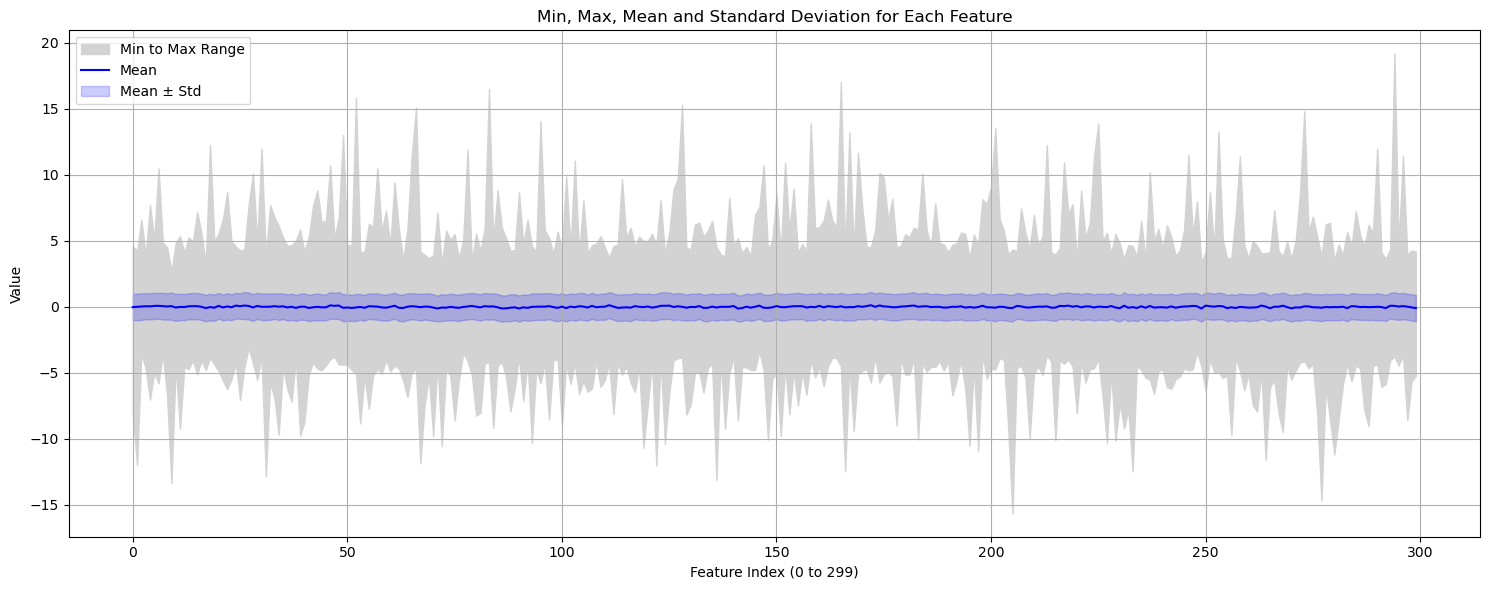

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# Transpose describe to get stats per feature
feature_stats = X_train.describe().T[["min", "max", "mean", "std"]]

# Get feature indices
x = np.arange(len(feature_stats))

# Mean ± Std bounds
mean = feature_stats["mean"].values
std = feature_stats["std"].values
min_vals = feature_stats["min"].values
max_vals = feature_stats["max"].values

# Plot
plt.figure(figsize=(15, 6))

# Plot Min and Max as a filled range
plt.fill_between(x, min_vals, max_vals, color='lightgray', label='Min to Max Range')

# Plot Mean
plt.plot(x, mean, color='blue', label='Mean')

# Plot Std as error band around Mean
plt.fill_between(x, mean - std, mean + std, color='blue', alpha=0.2, label='Mean ± Std')

plt.title("Min, Max, Mean and Standard Deviation for Each Feature")
plt.xlabel("Feature Index (0 to 299)")
plt.ylabel("Value")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Outlier Detection (Z-score > 3)

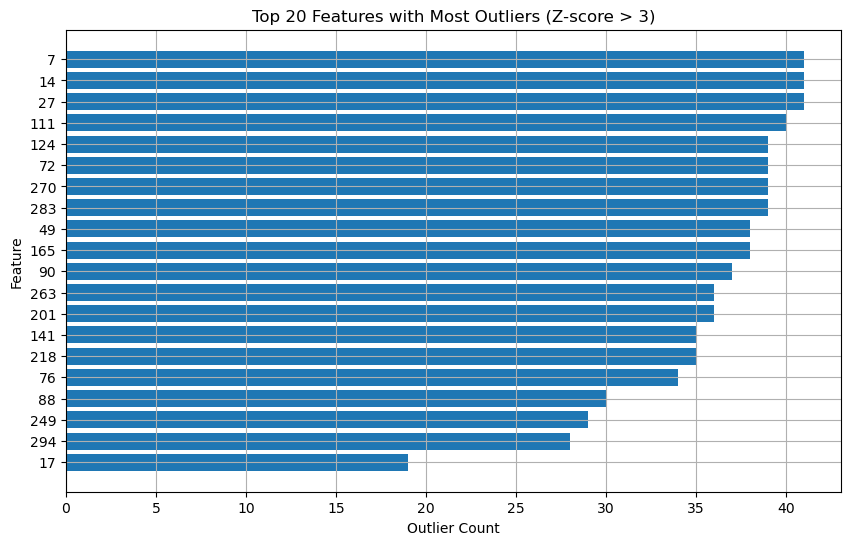

In [3]:
from scipy.stats import zscore
import numpy as np
import matplotlib.pyplot as plt

z_scores = np.abs(zscore(X_train))
outlier_flags = z_scores > 3  

outlier_counts = np.sum(outlier_flags, axis=0)

# Sort and plot top 20
top_features = np.argsort(outlier_counts)[:20]

plt.figure(figsize=(10,6))
plt.barh([f'{i}' for i in top_features], outlier_counts[top_features])
plt.title("Top 20 Features with Most Outliers (Z-score > 3)")
plt.xlabel("Outlier Count")
plt.ylabel("Feature")
plt.grid(True)
plt.show()



## Feature Skewness

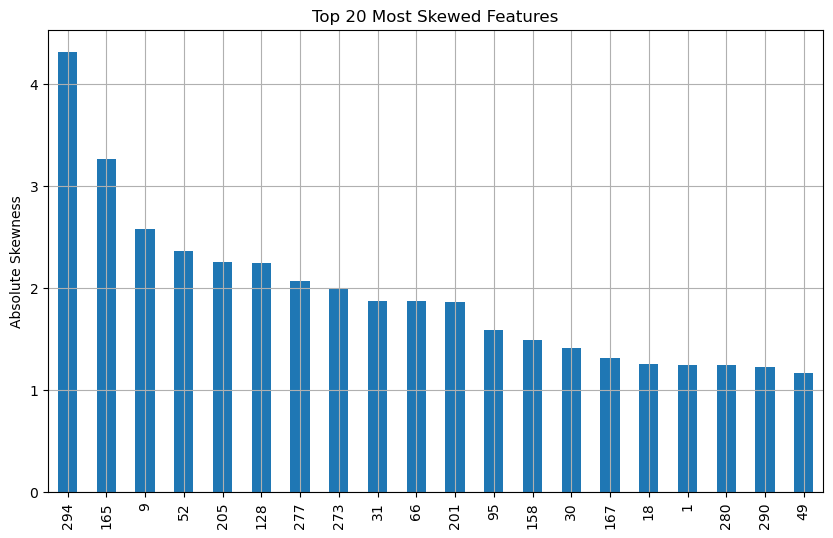

In [4]:
import matplotlib.pyplot as plt

skewness = X_train.skew()

top_skewed = skewness.abs().sort_values(ascending=False).head(20)

plt.figure(figsize=(10, 6))
top_skewed.plot(kind='bar')
plt.title("Top 20 Most Skewed Features")
plt.ylabel("Absolute Skewness")
plt.grid(True)
plt.show()


## Feature Correlation Analysis

In [5]:
import pandas as pd
import numpy as np

# Assuming X is your (10000 x 300) feature DataFrame
corr_matrix = X_train.corr()

# Get upper triangle of correlation matrix (to avoid duplicate pairs and self-correlation)
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

# Flatten the upper triangle into a list of pairs with their correlation
correlated_pairs = []

for col in upper.columns:
    for row in upper.index:
        corr_value = upper.loc[row, col]
        if pd.notnull(corr_value):
            correlated_pairs.append((row, col, corr_value))

# Sort by absolute correlation (strongest correlations first)
correlated_pairs.sort(key=lambda x: abs(x[2]), reverse=True)

# Convert to DataFrame for display
correlated_df = pd.DataFrame(correlated_pairs, columns=["Feature 1", "Feature 2", "Correlation"])

# Print the top 20 most correlated feature pairs
print("Top 20 most correlated feature pairs (by absolute value):\n")
print(correlated_df.head(20))


Top 20 most correlated feature pairs (by absolute value):

   Feature 1 Feature 2  Correlation
0         17        87     0.687621
1         88       218    -0.679775
2         27        88    -0.656537
3         76       249     0.651349
4         17       218    -0.629098
5         72       218    -0.625474
6         88       249     0.610552
7         27       249    -0.605289
8        124       172     0.596812
9        111       249    -0.596312
10        79       268     0.594595
11        48       263     0.594304
12        17        88     0.593439
13        46       249    -0.582562
14        86       268    -0.579688
15        76        88     0.578680
16        72        88     0.574501
17        27       218     0.569282
18        27       182     0.568703
19       218       249    -0.568073


## Class Distribution — Imbalance Check

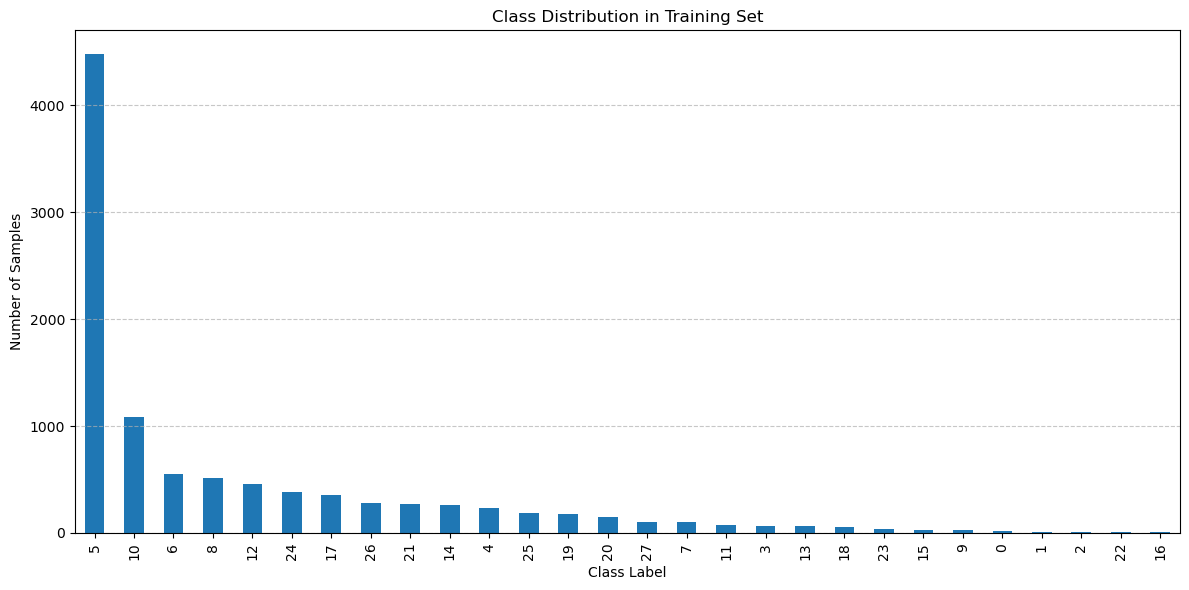

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Flatten the 2D array to 1D
y_flat = np.ravel(y_train)  # or y_train.flatten()

# Convert to pandas Series
y_series = pd.Series(y_flat)

# Count class occurrences
class_counts = y_series.value_counts().sort_values(ascending=False)

# Plot the bar chart
plt.figure(figsize=(12, 6))
class_counts.plot(kind='bar')
plt.title('Class Distribution in Training Set')
plt.xlabel('Class Label')
plt.ylabel('Number of Samples')
plt.xticks(rotation=90)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [7]:
print(class_counts)

5     4479
10    1081
6      553
8      516
12     457
24     385
17     354
26     278
21     269
14     264
4      238
25     184
19     177
20     153
27     107
7      103
11      78
3       65
13      62
18      60
23      41
15      26
9       25
0       18
1        7
2        7
22       7
16       6
Name: count, dtype: int64


## Covariate Shift — Training vs Test Set 2

We compare feature distributions between training data and Test Set 2 to check for distribution shift.

In [8]:
# Load test features
X_test1 = pd.read_csv("../raw datasets/X_test_1.csv")
X_test2 = pd.read_csv("../raw datasets/X_test_2.csv")

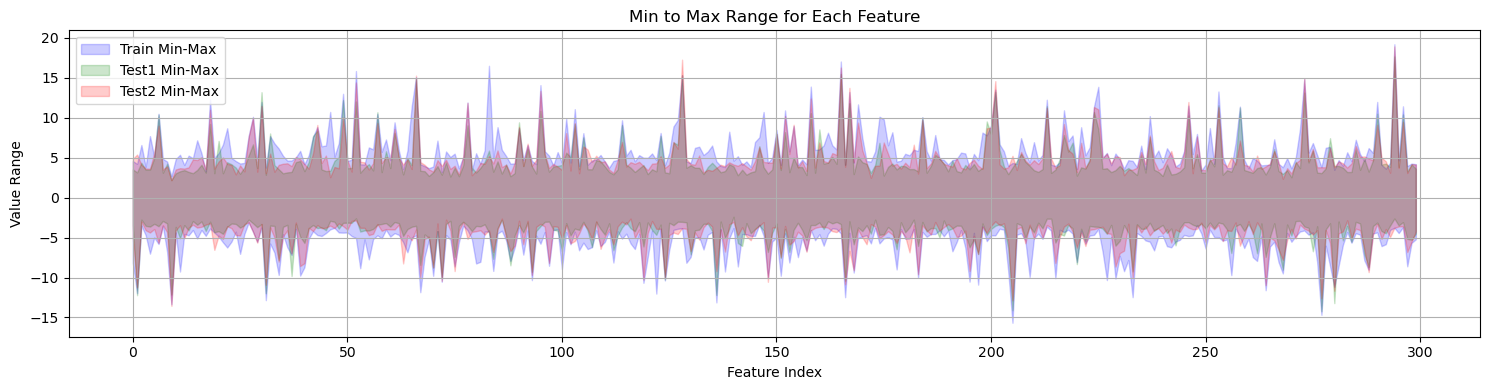

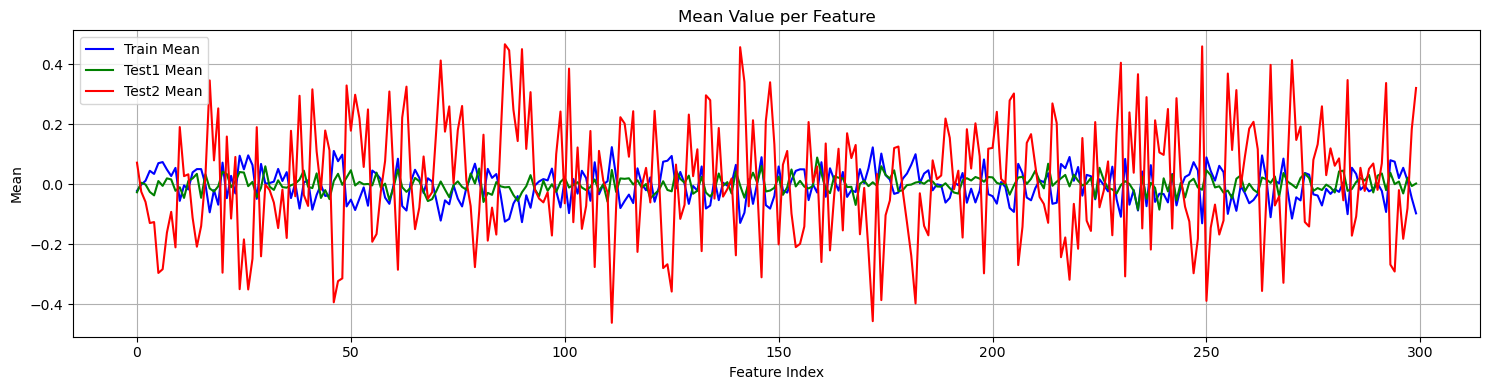

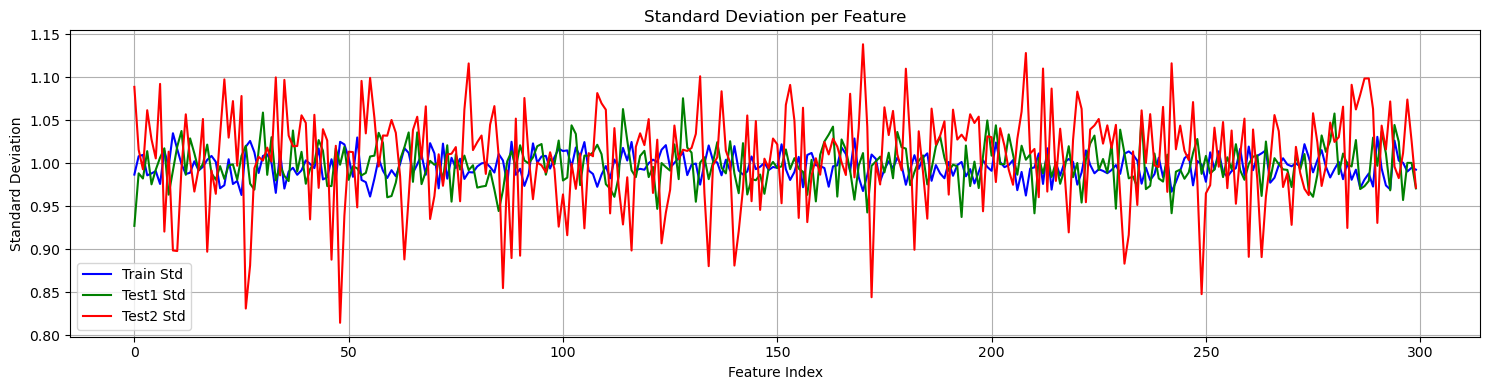

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Get feature-wise stats
def get_stats(df):
    stats = df.describe().T[["min", "max", "mean", "std"]]
    return stats

# Convert your test/train sets into DataFrames if they aren't already
df_train = pd.DataFrame(X_train)
df_test1 = pd.DataFrame(X_test1)
df_test2 = pd.DataFrame(X_test2)

# Get stats
stats_train = get_stats(df_train)
stats_test1 = get_stats(df_test1)
stats_test2 = get_stats(df_test2)

x = np.arange(len(stats_train))

# ----------------- Plot 1: Min vs Max Range -----------------
plt.figure(figsize=(15, 4))
plt.fill_between(x, stats_train["min"], stats_train["max"], color='blue', alpha=0.2, label='Train Min-Max')
plt.fill_between(x, stats_test1["min"], stats_test1["max"], color='green', alpha=0.2, label='Test1 Min-Max')
plt.fill_between(x, stats_test2["min"], stats_test2["max"], color='red', alpha=0.2, label='Test2 Min-Max')
plt.title("Min to Max Range for Each Feature")
plt.xlabel("Feature Index")
plt.ylabel("Value Range")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Plot 2: Mean Comparison -----------------
plt.figure(figsize=(15, 4))
plt.plot(x, stats_train["mean"], label='Train Mean', color='blue')
plt.plot(x, stats_test1["mean"], label='Test1 Mean', color='green')
plt.plot(x, stats_test2["mean"], label='Test2 Mean', color='red')
plt.title("Mean Value per Feature")
plt.xlabel("Feature Index")
plt.ylabel("Mean")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# ----------------- Plot 3: Standard Deviation Comparison -----------------
plt.figure(figsize=(15, 4))
plt.plot(x, stats_train["std"], label='Train Std', color='blue')
plt.plot(x, stats_test1["std"], label='Test1 Std', color='green')
plt.plot(x, stats_test2["std"], label='Test2 Std', color='red')
plt.title("Standard Deviation per Feature")
plt.xlabel("Feature Index")
plt.ylabel("Standard Deviation")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()